# AirLLM Lab — Results & Analysis

This notebook ties our measured numbers back to the *systems concepts* behind LLM
inference. It is fully reproducible: it re-loads the JSON artifacts in `results/`,
re-builds the cost report, and re-renders every figure in `assets/` through the
`LabSDK` facade (the same code path the CLI uses).

**The question:** can a 7B-parameter model run on a laptop with **4 GB VRAM** and
**~16 GB RAM**, and is doing so ever *economically* sensible versus a hosted API?

**The arc:**
1. **Baseline** — load the whole model into memory the naive way → it doesn't fit.
2. **AirLLM** — stream the network one layer at a time from disk → it *runs*, but
   pays a steep latency price (the classic time-vs-space trade-off / paging).
3. **Economics** — turn latency + energy + hardware cost into dollars and find the
   break-even versus an API.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Find the repo root (the dir holding config/setup.json) and run from there so
# every relative path resolves exactly like the CLI does.
ROOT = Path.cwd()
while not (ROOT / "config" / "setup.json").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

from airllm_lab.sdk import LabSDK

sdk = LabSDK()
# Regenerate the cost report + figures through the SDK so this notebook
# reproduces every artifact it then displays.
sdk.run_cost_analysis()
chart_paths = sdk.generate_charts()

RESULTS, ASSETS = ROOT / "results", ROOT / "assets"


def load(name: str):
    """Load a results JSON artifact by filename (or None if absent)."""
    path = RESULTS / name
    return json.loads(path.read_text("utf-8")) if path.exists() else None


print("repo root :", ROOT)
print("artifacts :", sorted(p.name for p in RESULTS.glob("*.json")))
print("figures   :", [Path(c).name for c in chart_paths])

repo root : D:\my programs\PycharmProjects\AI-orchestra-5
artifacts : ['airllm_Qwen2.5-7B-Instruct_fp16.json', 'baseline_Qwen2.5-7B-Instruct.json', 'benchmark_baseline_Qwen2.5-0.5B-Instruct_fp16.json', 'cost_analysis.json', 'hardware.json']
figures   : ['throughput.png', 'ttft.png', 'memory.png', 'cost_breakeven.png']


## 1. The hardware

Everything below is shaped by this machine. The two numbers that dominate the whole
story are **VRAM (4 GB)** and **RAM (~16 GB)**: a 7B model in FP16 needs ~15 GB
*just for weights*, so it fits in neither.

In [2]:
hw = load("hardware.json")
pd.DataFrame([hw]).T.rename(columns={0: "value"})

,value
cpu_cores,6
cpu_threads,12
ram_gb,15.8
gpu_name,NVIDIA GeForce GTX 1650
vram_gb,4.0
free_disk_gb,753.0


## 2. Stage 1 — the naive baseline (and why it fails)

The baseline runner loads the *entire* model into RAM, then moves it to the GPU.
Before doing so it runs a **feasibility check**: FP16 weights ≈ `params × 2 bytes`.
For 7B that is ~15 GB, which exceeds the ~8 GB of *free* RAM. So the baseline
fails fast with a recorded reason instead of thrashing swap and crashing the OS
(which is exactly what happened before the guard existed — a hard
`0xC0000005` process kill after ~28 minutes at 61% loaded).

This "failure" is a result: it is the empirical proof that we **need** a different
execution strategy.

In [3]:
baseline_7b = load("baseline_Qwen2.5-7B-Instruct.json")
print("7B naive baseline -> ok:", baseline_7b["ok"])
print("reason:", baseline_7b["error"])

7B naive baseline -> ok: False
reason: baseline infeasible: ~15.2 GB FP16 weights exceed ~8.3 GB available RAM (and 4 GB VRAM); the naive load thrashes swap and crashes the process


## 3. Prefill vs Decode — what TTFT and TPOT actually measure

Generation has two phases with very different hardware profiles:

- **Prefill** processes the whole prompt in one parallel pass and builds the
  KV-cache. It is **compute-bound** (lots of matmul, high arithmetic intensity).
  We measure it as **TTFT** — time to the first token.
- **Decode** then emits tokens one at a time; each step reads all the weights to
  produce a single token, so it is **memory-bandwidth-bound**. We measure it as
  **TPOT** — time per output token (and its inverse, throughput in tok/s).

A small 0.5B model that *fits* on the GPU gives us a healthy reference point for
both phases.

In [4]:
rows = []

bench_05b = load("benchmark_baseline_Qwen2.5-0.5B-Instruct_fp16.json")
if bench_05b and bench_05b["n_ok"]:
    agg = bench_05b["aggregates"]
    rows.append({
        "run": "0.5B baseline (GPU)",
        "TTFT_s": agg["ttft_s"]["mean"],
        "TPOT_s": agg["tpot_s"]["mean"],
        "throughput_tok_s": agg["throughput_tok_s"]["mean"],
        "peak_RAM_GB": agg["peak_ram_gb"]["mean"],
        "peak_VRAM_GB": agg["peak_vram_gb"]["mean"],
    })

air_7b = load("airllm_Qwen2.5-7B-Instruct_fp16.json")
if air_7b and air_7b["ok"]:
    rows.append({
        "run": "7B AirLLM (layered)",
        "TTFT_s": air_7b["ttft_s"],
        "TPOT_s": air_7b["tpot_s"],
        "throughput_tok_s": air_7b["throughput_tok_s"],
        "peak_RAM_GB": air_7b.get("peak_ram_gb", float("nan")),
        "peak_VRAM_GB": air_7b.get("peak_vram_gb", float("nan")),
    })

runs = pd.DataFrame(rows).set_index("run")
slowdown = runs.loc["0.5B baseline (GPU)", "throughput_tok_s"] / runs.loc[
    "7B AirLLM (layered)", "throughput_tok_s"
]
print(f"AirLLM decode is ~{slowdown:,.0f}x slower per token than the fitting baseline.")
runs

AirLLM decode is ~5,086x slower per token than the fitting baseline.


,TTFT_s,TPOT_s,throughput_tok_s,peak_RAM_GB,peak_VRAM_GB
run,,,,,
0.5B baseline (GPU),4.5602,0.1474,5.5950,2.2125,1.2485
7B AirLLM (layered),929.9112,923.0751,0.0011,NaN,NaN


## 4. Stage 2 — AirLLM: trading time for space (paging, basically)

AirLLM keeps the model **on disk** and loads exactly one transformer layer into
the GPU at a time: run layer *i*, free it, load layer *i+1*. Peak memory therefore
scales with **one layer**, not the whole model — which is why a 7B model "fits" on
4 GB of VRAM at all.

The cost is bandwidth. Every single decode step now streams the full set of layer
weights from an **HDD** through the bus into the GPU. That is the operating-system
**paging / virtual-memory** analogy made literal: we extended capacity by treating
disk as memory, and we pay for it in latency. The charts below show the result on a
**log scale** — the only way both runs are visible at once.

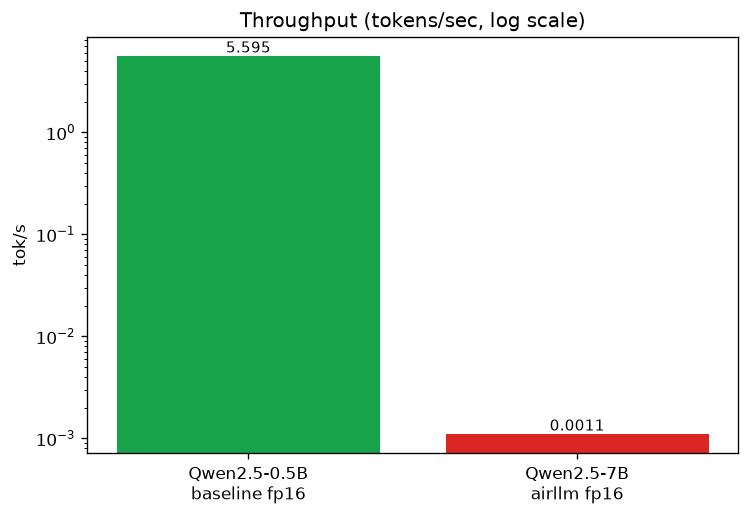

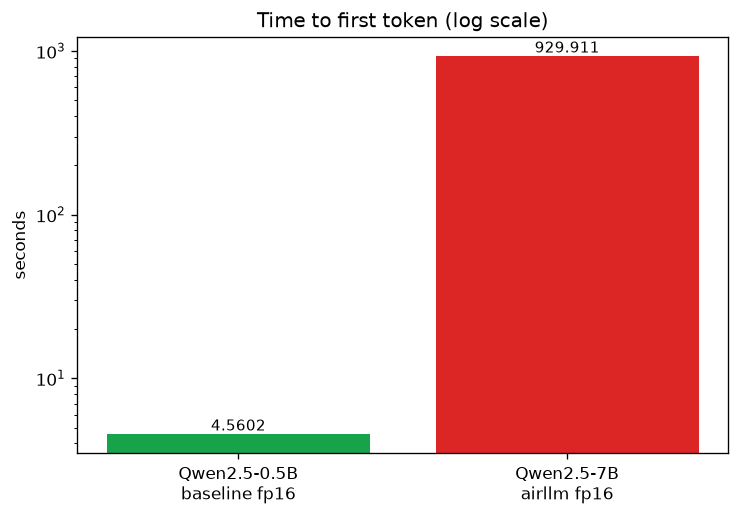

In [5]:
for fig in ("throughput.png", "ttft.png"):
    path = ASSETS / fig
    if path.exists():
        display(Image(filename=str(path)))

## 5. Memory footprint

The fitting 0.5B baseline shows a modest, stable peak RAM/VRAM. AirLLM's whole
point is that its peak memory stays small *regardless of model size* — it is
bounded by a single layer, not by 7B of weights.

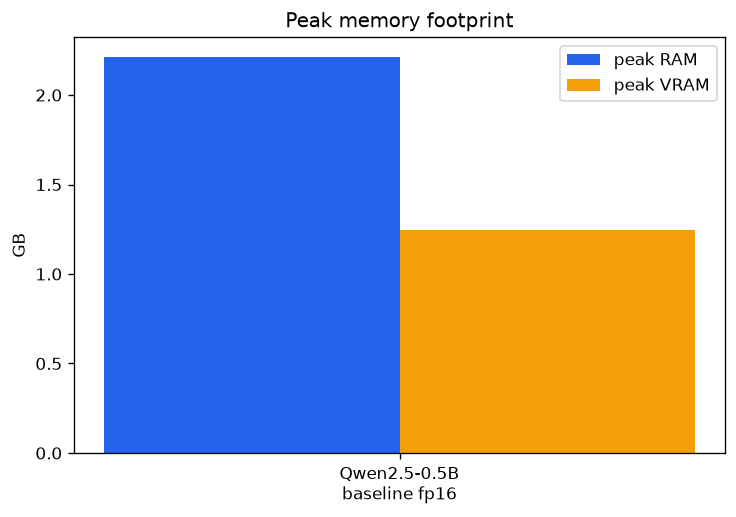

In [6]:
mem = ASSETS / "memory.png"
if mem.exists():
    display(Image(filename=str(mem)))

## 6. Economics — is local ever cheaper than an API?

We compare three options against monthly request volume (all assumptions live in
`config/setup.json`, dated and editable):

- **Hosted API** — per-token price, with an optional cached-prefix discount.
- **OnPrem** — amortized hardware **CAPEX** + electricity **OPEX**.
- **Cloud GPU** — pay-as-you-go hourly rental.

**Break-even** is the volume where OnPrem's fixed monthly cost is finally
out-amortized by the API's per-request charge.

break-even (OnPrem vs API): 239,464 requests/month


,per_request_USD,monthly_USD
API,0.000255,2.5500
OnPrem,0.004248,42.4767
Cloud GPU,0.004167,41.6700


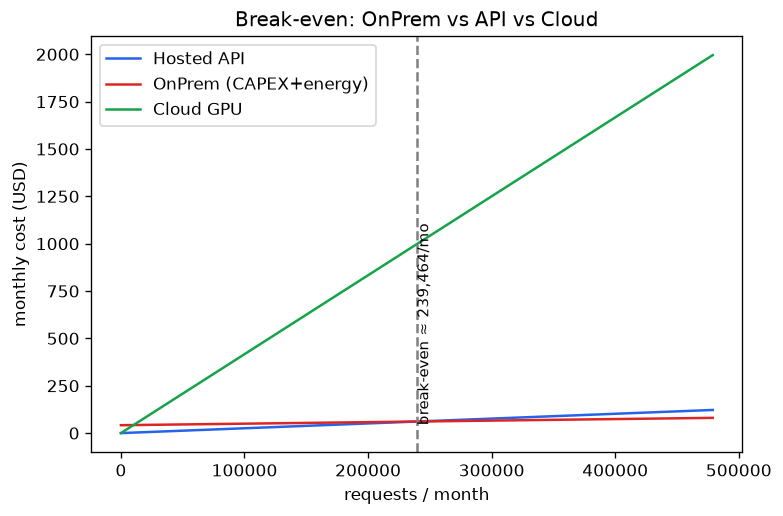

In [7]:
cost = load("cost_analysis.json")
summary = pd.DataFrame(
    {
        "per_request_USD": {
            "API": cost["api_per_request"],
            "OnPrem": cost["onprem_per_request"],
            "Cloud GPU": cost["cloud_per_request"],
        },
        "monthly_USD": {
            "API": cost["api_monthly"],
            "OnPrem": cost["onprem_monthly"],
            "Cloud GPU": cost["cloud_monthly"],
        },
    }
)
be = cost["breakeven_requests_per_month"]
print(f"break-even (OnPrem vs API): {be:,.0f} requests/month" if be else
      "OnPrem never breaks even: local energy alone already costs more than the API.")
display(summary)

img = ASSETS / "cost_breakeven.png"
if img.exists():
    display(Image(filename=str(img)))

## 7. Conclusions

- **Feasibility ≠ practicality.** AirLLM makes a 7B model *run* on 4 GB of VRAM, but
  decode is bandwidth-starved by the disk, so throughput collapses by ~10³–10⁴×.
  On this hardware it is a correctness demo, not a serving solution.
- **The bottleneck is memory bandwidth, not compute.** Prefill (TTFT) and decode
  (TPOT) degrade together because every token now waits on layer weights streaming
  from disk — the literal version of OS paging.
- **Economics strongly favour the API at any modest volume.** Even with a generous
  "efficient local" runtime assumption, OnPrem only wins at a very high monthly
  volume; with the *measured* AirLLM runtime the local energy bill alone exceeds the
  API price, so it never breaks even.
- **Cost is not the only axis.** OnPrem/local still wins on **data privacy, offline
  operation, and no per-call dependency** — relevant when inputs cannot leave the
  premises. The honest recommendation is API for cost/latency, local only when
  privacy or air-gapping is a hard requirement.

*Next: re-run the benchmark across quant levels (FP16/Q8/Q4) and overlay the points
on these same charts to see how quantization shifts throughput, memory, and the
break-even.*